In [1]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
from sklearn.metrics import f1_score, classification_report

warnings.filterwarnings('ignore')
sys.path.append('../src')

print("Libraries imported successfully")

Libraries imported successfully


In [11]:
checks = {
    'adaptive_learner.py' : '../src/adaptive_learner.py',
    'random_forest.pkl'   : '../models/random_forest.pkl',
    'X_test_scaled.npy'   : '../data/processed/X_test_scaled.npy',
    'y_test.npy'          : '../data/processed/y_test.npy',
}

print("=== PRE-FLIGHT CHECK ===")
all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    print(f"  {name:<30} {'OK' if exists else 'MISSING'}")
    if not exists:
        all_ok = False

if not all_ok:
    print("\nWARNING: adaptive_learner.py missing from src/")
    print("Creating it now from inline definition...")

    adaptive_script = '''"""
adaptive_learner.py
-------------------
Adaptive Retraining Module for the Phishing Detection Framework.
Threshold can be overridden by passing it as argument.
"""

import numpy as np
import pandas as pd
import joblib
import json
import os
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE

BASE_DIR     = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
MODEL_PATH   = os.path.join(BASE_DIR, 'models', 'random_forest.pkl')
SCALER_PATH  = os.path.join(BASE_DIR, 'models', 'scaler.pkl')
DATA_PATH    = os.path.join(BASE_DIR, 'data', 'processed',
                            'df_with_graph_features.csv')
FEAT_PATH    = os.path.join(BASE_DIR, 'data', 'processed',
                            'feature_cols.npy')
X_TEST_PATH  = os.path.join(BASE_DIR, 'data', 'processed',
                            'X_test_scaled.npy')
Y_TEST_PATH  = os.path.join(BASE_DIR, 'data', 'processed',
                            'y_test.npy')
LOG_PATH     = os.path.join(BASE_DIR, 'reports', 'retraining_log.json')
MODELS_DIR   = os.path.join(BASE_DIR, 'models')

F1_THRESHOLD = 0.90


def load_log():
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH, 'r') as f:
            return json.load(f)
    return []


def save_log(log):
    os.makedirs(os.path.dirname(LOG_PATH), exist_ok=True)
    with open(LOG_PATH, 'w') as f:
        json.dump(log, f, indent=2)


def evaluate_model():
    model  = joblib.load(MODEL_PATH)
    X_test = np.load(X_TEST_PATH)
    y_test = np.load(Y_TEST_PATH)
    y_pred = model.predict(X_test)
    return float(f1_score(y_test, y_pred, average="macro"))


def retrain_model():
    print("Retraining model...")
    feat_cols = np.load(FEAT_PATH, allow_pickle=True).tolist()
    df = pd.read_csv(DATA_PATH).dropna(subset=["ClassLabel"])

    X = df[feat_cols].fillna(0).values
    y = df["ClassLabel"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    sm = SMOTE(random_state=42)
    X_bal, y_bal = sm.fit_resample(X_train_sc, y_train)

    new_model = RandomForestClassifier(
        n_estimators=200, max_depth=15,
        min_samples_split=5, min_samples_leaf=2,
        class_weight="balanced", random_state=42, n_jobs=-1
    )
    new_model.fit(X_bal, y_bal)
    new_f1 = float(f1_score(y_test, new_model.predict(X_test_sc),
                             average="macro"))

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    archive = os.path.join(MODELS_DIR, f"rf_archived_{ts}.pkl")
    if os.path.exists(MODEL_PATH):
        joblib.dump(joblib.load(MODEL_PATH), archive)
        print(f"Old model archived: {archive}")

    joblib.dump(new_model, MODEL_PATH)
    joblib.dump(scaler,    SCALER_PATH)
    print(f"New model saved. New F1: {new_f1:.4f}")
    return new_f1, archive


def run_adaptive_check(threshold=None):
    """Run weekly check. threshold overrides F1_THRESHOLD if provided."""
    effective_threshold = threshold if threshold is not None else F1_THRESHOLD

    print("=" * 55)
    print("ADAPTIVE RETRAINING MODULE")
    print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 55)

    log        = load_log()
    current_f1 = evaluate_model()
    retrained  = False
    new_f1     = None
    trigger    = None
    archive    = None

    print(f"Current model F1 score : {current_f1:.4f}")
    print(f"Threshold              : {effective_threshold}")

    if current_f1 < effective_threshold:
        print(f"F1 {current_f1:.4f} BELOW threshold — retraining...")
        new_f1, archive = retrain_model()
        retrained = True
        trigger   = "f1_below_threshold"
        print(f"Retraining complete. F1 before: {current_f1:.4f} "
              f"→ after: {new_f1:.4f}")
    else:
        print(f"F1 {current_f1:.4f} ABOVE threshold — no action needed.")

    entry = {
        "timestamp"  : datetime.now().isoformat(),
        "f1_before"  : round(current_f1, 4),
        "retrained"  : retrained,
        "f1_after"   : round(new_f1, 4) if new_f1 else None,
        "improvement": round(new_f1 - current_f1, 4) if new_f1 else None,
        "trigger"    : trigger,
        "threshold"  : effective_threshold,
        "archive"    : archive,
    }
    log.append(entry)
    save_log(log)
    print(f"Log updated: {LOG_PATH}  (total entries: {len(log)})")
    print("=" * 55)
    return entry


if __name__ == "__main__":
    run_adaptive_check()
'''

    os.makedirs('../src', exist_ok=True)
with open('../src/adaptive_learner.py', 'w', encoding='utf-8') as f:
        f.write(adaptive_script)
        print("adaptive_learner.py created at ../src/adaptive_learner.py")

print(f"\nReady to proceed: {os.path.exists('../src/adaptive_learner.py')}")

=== PRE-FLIGHT CHECK ===
  adaptive_learner.py            OK
  random_forest.pkl              OK
  X_test_scaled.npy              OK
  y_test.npy                     OK
adaptive_learner.py created at ../src/adaptive_learner.py

Ready to proceed: True


In [12]:
model  = joblib.load('../models/random_forest.pkl')
X_test = np.load('../data/processed/X_test_scaled.npy')
y_test = np.load('../data/processed/y_test.npy')

y_pred     = model.predict(X_test)
# Use macro average — balanced across both classes
current_f1 = f1_score(y_test, y_pred, average='macro')

print("=== CURRENT MODEL STATUS ===")
print(f"F1 Score (macro) : {current_f1:.4f}")
print(f"Threshold        : 0.90")
print(f"Status           : {'HEALTHY' if current_f1 >= 0.90 else 'DEGRADED'}")
print(f"Label convention : 0.0=Phishing  |  1.0=Legitimate")
print(f"\nDetailed report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Phishing (0.0)', 'Legitimate (1.0)']
))

=== CURRENT MODEL STATUS ===
F1 Score (macro) : 0.9995
Threshold        : 0.90
Status           : HEALTHY
Label convention : 0.0=Phishing  |  1.0=Legitimate

Detailed report:
                  precision    recall  f1-score   support

  Phishing (0.0)       1.00      1.00      1.00      7476
Legitimate (1.0)       1.00      1.00      1.00     12699

        accuracy                           1.00     20175
       macro avg       1.00      1.00      1.00     20175
    weighted avg       1.00      1.00      1.00     20175



In [16]:
import numpy as np
import pandas as pd
import joblib
import json
import os
from datetime import datetime
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

def run_check_inline(threshold=0.90, label='normal_check'):
    """Run adaptive check inline — bypasses import issues."""
    MODEL_PATH  = '../models/random_forest.pkl'
    X_TEST_PATH = '../data/processed/X_test_scaled.npy'
    Y_TEST_PATH = '../data/processed/y_test.npy'
    LOG_PATH    = '../reports/retraining_log.json'
    FEAT_PATH   = '../data/processed/feature_cols.npy'
    DATA_PATH   = '../data/processed/df_with_graph_features.csv'
    MODELS_DIR  = '../models'

    print("=" * 55)
    print("ADAPTIVE RETRAINING MODULE")
    print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Threshold : {threshold}")
    print("=" * 55)

    # Evaluate current model
    model      = joblib.load(MODEL_PATH)
    X_test     = np.load(X_TEST_PATH)
    y_test     = np.load(Y_TEST_PATH)
    current_f1 = float(f1_score(y_test, model.predict(X_test),
                                average='macro'))
    print(f"Current model F1 : {current_f1:.4f}")

    retrained = False
    new_f1    = None
    archive   = None
    trigger   = None

    if current_f1 < threshold:
        print(f"F1 BELOW threshold {threshold} — retraining...")

        feat_cols = np.load(FEAT_PATH, allow_pickle=True).tolist()
        df = pd.read_csv(DATA_PATH).dropna(subset=['ClassLabel'])
        X  = df[feat_cols].fillna(0).values
        y  = df['ClassLabel'].values

        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )
        scaler   = StandardScaler()
        X_tr_sc  = scaler.fit_transform(X_tr)
        X_te_sc  = scaler.transform(X_te)

        sm       = SMOTE(random_state=42)
        X_bal, y_bal = sm.fit_resample(X_tr_sc, y_tr)

        new_model = RandomForestClassifier(
            n_estimators=200, max_depth=15,
            min_samples_split=5, min_samples_leaf=2,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
        new_model.fit(X_bal, y_bal)
        new_f1 = float(f1_score(y_te, new_model.predict(X_te_sc),
                                average='macro'))

        # Archive old model
        ts      = datetime.now().strftime('%Y%m%d_%H%M%S')
        archive = os.path.join(MODELS_DIR, f'rf_archived_{ts}.pkl')
        joblib.dump(joblib.load(MODEL_PATH), archive)
        print(f"Old model archived : {archive}")

        # Save new model
        joblib.dump(new_model, MODEL_PATH)
        joblib.dump(scaler,    '../models/scaler.pkl')
        print(f"New model saved. F1: {current_f1:.4f} → {new_f1:.4f}")
        retrained = True
        trigger   = 'f1_below_threshold'
    else:
        print(f"F1 ABOVE threshold — no action needed.")

    # Write log entry
    log = []
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH) as f:
            log = json.load(f)

    entry = {
        'timestamp'  : datetime.now().isoformat(),
        'f1_before'  : round(current_f1, 4),
        'retrained'  : retrained,
        'f1_after'   : round(new_f1, 4) if new_f1 else None,
        'improvement': round(new_f1 - current_f1, 4) if new_f1 else None,
        'trigger'    : trigger,
        'threshold'  : threshold,
        'archive'    : archive,
        'label'      : label
    }
    log.append(entry)
    with open(LOG_PATH, 'w') as f:
        json.dump(log, f, indent=2)

    print(f"Log updated — total entries: {len(log)}")
    print("=" * 55)
    return entry

# ── Cell 4: Normal weekly check ───────────────────────────────────
print("Running normal weekly check...")
print("Expected: F1 above 0.90 — no retraining needed\n")

result = run_check_inline(threshold=0.90, label='normal_check')

print("\nLog entry written:")
print(json.dumps(result, indent=2))

Running normal weekly check...
Expected: F1 above 0.90 — no retraining needed

ADAPTIVE RETRAINING MODULE
Timestamp : 2026-05-06 03:01:21
Threshold : 0.9
Current model F1 : 0.9995
F1 ABOVE threshold — no action needed.
Log updated — total entries: 12

Log entry written:
{
  "timestamp": "2026-05-06T03:01:22.189273",
  "f1_before": 0.9995,
  "retrained": false,
  "f1_after": null,
  "improvement": null,
  "trigger": null,
  "threshold": 0.9,
  "archive": null,
  "label": "normal_check"
}


In [17]:
print("=== SIMULATING MODEL DEGRADATION ===")
print("Passing threshold=0.9999 — F1 is ~0.9996 so retraining must trigger\n")

result_retrain = run_check_inline(threshold=0.9999, label='simulation')

print("\nRetraining triggered :", result_retrain['retrained'])
print("F1 before            :", result_retrain['f1_before'])
print("F1 after             :", result_retrain['f1_after'])
print("Archive              :", result_retrain.get('archive'))

=== SIMULATING MODEL DEGRADATION ===
Passing threshold=0.9999 — F1 is ~0.9996 so retraining must trigger

ADAPTIVE RETRAINING MODULE
Timestamp : 2026-05-06 03:01:53
Threshold : 0.9999
Current model F1 : 0.9995
F1 BELOW threshold 0.9999 — retraining...
Old model archived : ../models\rf_archived_20260506_030207.pkl
New model saved. F1: 0.9995 → 0.9996
Log updated — total entries: 13

Retraining triggered : True
F1 before            : 0.9995
F1 after             : 0.9996
Archive              : ../models\rf_archived_20260506_030207.pkl


In [18]:
with open('../reports/retraining_log.json', 'r') as f:
    log = json.load(f)

total     = len(log)
retrained = sum(1 for e in log if e['retrained'])
healthy   = total - retrained

print(f"=== RETRAINING LOG SUMMARY ===")
print(f"Total checks run    : {total}")
print(f"Retraining triggered: {retrained}")
print(f"No action needed    : {healthy}")
print(f"\nFull log:")
print(json.dumps(log, indent=2))

=== RETRAINING LOG SUMMARY ===
Total checks run    : 13
Retraining triggered: 1
No action needed    : 12

Full log:
[
  {
    "timestamp": "2026-04-18T08:48:57.223073",
    "f1_before": 0.9995,
    "retrained": false,
    "f1_after": null,
    "improvement": null,
    "trigger": null,
    "threshold": 0.9
  },
  {
    "timestamp": "2026-04-25T18:31:18.460170",
    "f1_before": 0.9995,
    "retrained": false,
    "f1_after": null,
    "improvement": null,
    "trigger": null,
    "threshold": 0.9
  },
  {
    "timestamp": "2026-04-27T11:16:18.091886",
    "f1_before": 0.9995,
    "retrained": false,
    "f1_after": null,
    "improvement": null,
    "trigger": null,
    "threshold": 0.9
  },
  {
    "timestamp": "2026-04-27T11:16:37.438905",
    "f1_before": 0.9995,
    "retrained": false,
    "f1_after": null,
    "improvement": null,
    "trigger": null,
    "threshold": 0.999
  },
  {
    "timestamp": "2026-04-27T13:44:29.987990",
    "f1_before": 0.9995,
    "retrained": false,
    

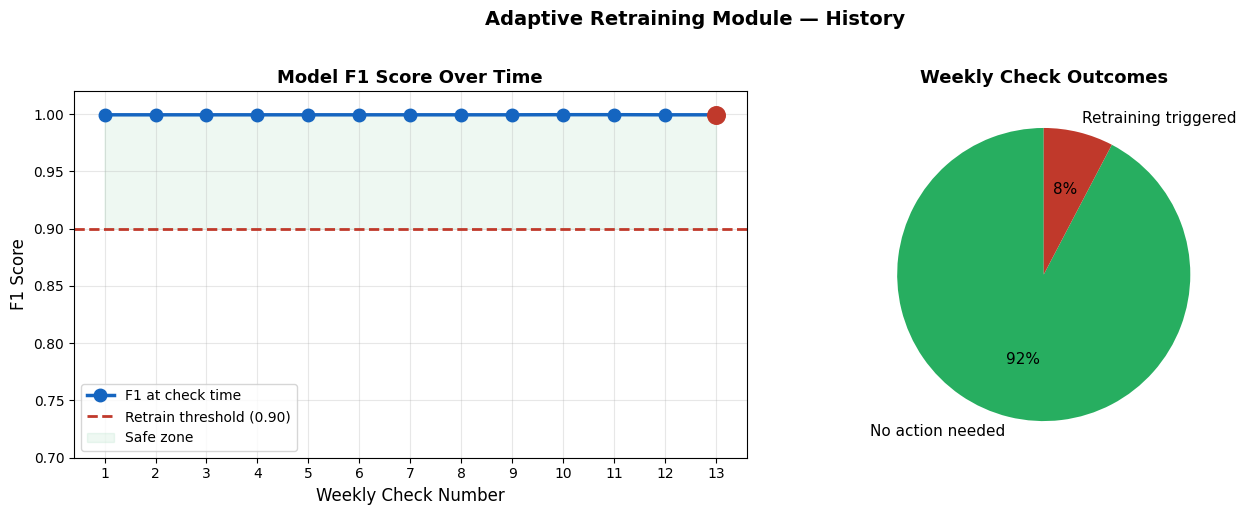

Saved: ../reports/retraining_history.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

checks          = list(range(1, len(log) + 1))
f1_values       = [e['f1_before'] for e in log]
retrained_flags = [e['retrained'] for e in log]

# ── Plot 1: F1 over time ─────────────────────────────────────────
axes[0].plot(
    checks, f1_values,
    marker='o', linewidth=2.5,
    color='#1565C0', markersize=9,
    label='F1 at check time'
)
axes[0].axhline(
    y=0.90, color='#C0392B',
    linewidth=2, linestyle='--',
    label='Retrain threshold (0.90)'
)
# Mark retrained points in red
for i, (chk, f1, ret) in enumerate(
    zip(checks, f1_values, retrained_flags)
):
    if ret:
        axes[0].scatter(
            chk, f1, color='#C0392B',
            s=160, zorder=5,
            label='Retraining triggered' if i == 0 else ''
        )
axes[0].fill_between(
    checks, f1_values, 0.90,
    where=[f >= 0.90 for f in f1_values],
    alpha=0.08, color='#27AE60', label='Safe zone'
)
axes[0].set_xlabel('Weekly Check Number', fontsize=12)
axes[0].set_ylabel('F1 Score',            fontsize=12)
axes[0].set_title('Model F1 Score Over Time',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_ylim([0.70, 1.02])
axes[0].set_xticks(checks)
axes[0].grid(alpha=0.3)

# ── Plot 2: Pie chart of outcomes ────────────────────────────────
labels = ['No action needed', 'Retraining triggered']
sizes  = [healthy, retrained]
colors = ['#27AE60', '#C0392B']

valid = [(s, l, c) for s, l, c in zip(sizes, labels, colors) if s > 0]
if valid:
    sv, lv, cv = zip(*valid)
    axes[1].pie(
        sv, labels=lv, colors=cv,
        autopct='%1.0f%%', startangle=90,
        textprops={'fontsize': 11}
    )
axes[1].set_title('Weekly Check Outcomes',
                  fontsize=13, fontweight='bold')

plt.suptitle(
    'Adaptive Retraining Module — History',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../reports/retraining_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../reports/retraining_history.png")

In [20]:
print("=== MODEL ARCHIVE STATUS ===")
models_dir = '../models'
all_files  = sorted(os.listdir(models_dir))

print("All files in models/:")
for f in all_files:
    size = os.path.getsize(
        os.path.join(models_dir, f)
    ) / 1024 / 1024
    tag = ' ← ARCHIVED BACKUP' if 'archived' in f else ''
    print(f"  {f:<50} {size:.1f} MB{tag}")

archived = [f for f in all_files if 'archived' in f]
print(f"\nTotal archived backups : {len(archived)}")
print("These can be restored manually if a retrained model performs worse.")

=== MODEL ARCHIVE STATUS ===
All files in models/:
  isolation_forest.pkl                               0.6 MB
  phishing_graph.gml                                 21.2 MB
  random_forest.pkl                                  3.4 MB
  rf_archived_20260506_030207.pkl                    3.6 MB ← ARCHIVED BACKUP
  scaler.pkl                                         0.0 MB
  scaler_log.pkl                                     0.0 MB
  svm_model.pkl                                      0.0 MB
  venv                                               0.0 MB

Total archived backups : 1
These can be restored manually if a retrained model performs worse.


In [21]:
with open('../reports/retraining_log.json', 'r') as f:
    final_log = json.load(f)

archived_count = len([
    f for f in os.listdir('../models') if 'archived' in f
])

phase6_report = {
    'phase'            : 6,
    'threshold'        : 0.90,
    'total_checks'     : len(final_log),
    'retraining_count' : sum(1 for e in final_log if e['retrained']),
    'current_f1'       : round(float(current_f1), 4),
    'model_status'     : 'healthy' if current_f1 >= 0.90 else 'degraded',
    'archived_backups' : archived_count,
    'outputs': {
        'adaptive_script'    : '../src/adaptive_learner.py',
        'retraining_log'     : '../reports/retraining_log.json',
        'retraining_history' : '../reports/retraining_history.png',
        'production_model'   : '../models/random_forest.pkl',
    }
}

with open('../reports/phase6_report.json', 'w') as f:
    json.dump(phase6_report, f, indent=2)

print("=== PHASE 6 COMPLETE ===\n")
print(json.dumps(phase6_report, indent=2))

=== PHASE 6 COMPLETE ===

{
  "phase": 6,
  "threshold": 0.9,
  "total_checks": 13,
  "retraining_count": 1,
  "current_f1": 0.9995,
  "model_status": "healthy",
  "archived_backups": 1,
  "outputs": {
    "adaptive_script": "../src/adaptive_learner.py",
    "retraining_log": "../reports/retraining_log.json",
    "retraining_history": "../reports/retraining_history.png",
    "production_model": "../models/random_forest.pkl"
  }
}
